# 08. Anatomy of an Error — Biology, Annotation, or Artifact?

`06_error_analysis.md` looked at the confusion matrix from notebook 04 and the merged
Harmony clusters from notebook 02 and offered biological explanations: acinar-to-ductal
metaplasia, shared endocrine lineage, stellate cell *states* rather than types. Those
are plausible stories. They are also untested — no gene was ever looked at, no doublet
score computed, no check of which study the "confused" cells came from. This notebook
does the checking.

For every recurring error there are four competing explanations, and they lead to
different conclusions about the data and about the model:

| Hypothesis | What it would look like |
|---|---|
| **H1 — annotation / study-specific** | the cells come from one study or one donor; their marker profile matches the *predicted* type, not the annotated one |
| **H2 — doublet / multiplet** | elevated doublet score and library size; markers of *both* types present |
| **H3 — ambient contamination** | the "foreign" marker is present at the same low level as in every other cell of that technology |
| **H4 — genuine intermediate / co-expressing state** | both markers clearly expressed, normal doublet score, normal library size, reproducible across studies |

Two sources of "errors" are examined:

* **Part A** — the impure Harmony clusters at resolution 0.3 (the crosstab that
  `06` described but that never made it into notebook 02).
* **Parts B–E** — the scANVI label-transfer errors on the held-out `smartseq2` cells,
  now filtered through the five seeds of notebook 07: an error that survives 4 of 5
  random initializations is a property of the cell; one that appears in a single seed
  is a property of the model.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sc.settings.verbosity = 1
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

HOLDOUT_TECH = "smartseq2"

MARKERS = {
    "endocrine": ["INS", "IAPP", "GCG", "ARX", "IRX2", "SST", "HHEX", "PPY", "GHRL", "CHGA"],
    "acinar":    ["PRSS1", "CPA1", "CTRB1", "CELA3A", "PNLIP", "PTF1A", "REG1A"],
    "ductal":    ["KRT19", "SOX9", "CFTR", "SPP1", "MMP7", "KRT7"],
    "other":     ["MKI67", "TOP2A", "COL1A1", "RGS5", "PECAM1", "CD68", "TPSAB1"],
}
MARKER_LIST = sum(MARKERS.values(), [])

# one defining marker per cell type, used for the pairwise co-expression tests
TYPE_MARKER = {"alpha": "GCG", "beta": "INS", "delta": "SST", "gamma": "PPY", "epsilon": "GHRL",
               "acinar": "PRSS1", "ductal": "KRT19", "activated_stellate": "COL1A1",
               "quiescent_stellate": "RGS5", "endothelial": "PECAM1", "macrophage": "CD68",
               "mast": "TPSAB1"}

HORMONES = ["INS", "GCG", "SST", "PPY"]                       # endocrine "leak" into exocrine cells
ENZYMES = ["PRSS1", "CPA1", "CTRB1", "CELA3A", "PNLIP", "CPB1"]  # acinar "leak" into endocrine cells

## 1. Assemble everything into one `obs` table

The raw object carries the full gene set (`X` is scran-normalized and log-transformed,
`layers["counts"]` the reconstructed counts). Predictions and clusters come from the
saved outputs of notebooks 02 and 04, the per-seed predictions from notebook 07. The two
dense 16k × 19k matrices are used once — for marker expression and for count fractions —
and then dropped.

In [2]:
adata = sc.read_h5ad("../data/raw/pancreas.h5ad")
scanvi_obs = sc.read_h5ad("../data/processed/pancreas_scanvi.h5ad", backed="r").obs
harmony_obs = sc.read_h5ad("../data/processed/pancreas_harmony.h5ad", backed="r").obs
assert (adata.obs_names == scanvi_obs.index).all() and (adata.obs_names == harmony_obs.index).all()

adata.obs["scanvi_pred_ref"] = scanvi_obs["celltype_predicted"].astype(str).values  # reference run, notebook 04
adata.obs["harmony_cluster"] = harmony_obs["leiden_r0.3"].astype(str).values          # notebook 02, resolution 0.3

seed_preds = pd.read_csv("../results/seed_predictions_smartseq2.csv", index_col=0)
PRED_COLS = [c for c in seed_preds.columns if c.startswith("pred_seed")]
CONF_COLS = [c for c in seed_preds.columns if c.startswith("conf_seed")]
print("seeds available:", len(PRED_COLS))

# library size / complexity from the counts layer
sc.pp.calculate_qc_metrics(adata, layer="counts", percent_top=None, log1p=False, inplace=True)

counts = adata.layers["counts"]
total = np.asarray(counts.sum(axis=1)).ravel()
adata.obs["frac_hormone_counts"] = np.asarray(counts[:, adata.var_names.get_indexer(HORMONES)].sum(axis=1)).ravel() / total
adata.obs["frac_enzyme_counts"] = np.asarray(counts[:, adata.var_names.get_indexer(ENZYMES)].sum(axis=1)).ravel() / total

# log-normalized expression of the marker panel, all cells
expr = pd.DataFrame(np.asarray(adata[:, MARKER_LIST].X), index=adata.obs_names, columns=MARKER_LIST)

# a small object for doublet scoring: the held-out technology plus the two batches that matter in Part A
sub = adata[adata.obs["tech"].isin([HOLDOUT_TECH, "inDrop2", "inDrop4"])].copy()
obs = adata.obs.copy()
del adata, counts
obs[["tech", "celltype", "scanvi_pred_ref", "harmony_cluster", "total_counts", "n_genes_by_counts"]].head()

seeds available: 5


,tech,celltype,scanvi_pred_ref,harmony_cluster,total_counts,n_genes_by_counts
D101_5,celseq,gamma,gamma,0,4057.480225,1857
D101_43,celseq,gamma,gamma,0,10604.392578,3724
D101_93,celseq,gamma,gamma,0,4921.611328,2261
D102_4,celseq,gamma,gamma,0,6157.592773,2653
D172444_23,celseq,gamma,gamma,0,4803.836426,2230


## Part A — What the Harmony merges are actually made of

The crosstab `06` refers to, restored. Then, for every sizeable group of cells sitting in
a cluster dominated by a *different* cell type, the question that was never asked: which
technology are they from?

In [3]:
ct = pd.crosstab(obs["harmony_cluster"], obs["celltype"])
ct.index = ct.index.astype(int); ct = ct.sort_index()
dominant = ct.idxmax(axis=1)
ct.assign(dominant=dominant)

celltype,acinar,activated_stellate,alpha,beta,delta,ductal,endothelial,epsilon,gamma,macrophage,mast,quiescent_stellate,schwann,t_cell,dominant
harmony_cluster,,,,,,,,,,,,,,,
0,0,0,7,5,0,0,0,16,688,0,0,0,0,0,gamma
1,0,0,168,14,8,21,0,4,5,0,0,0,0,0,alpha
2,2,0,2,1,0,1917,0,0,0,0,0,0,0,0,ductal
3,0,0,5203,6,6,3,0,3,4,0,0,0,0,0,alpha
4,1654,0,27,19,2,193,0,0,1,0,0,0,0,0,acinar
5,2,0,12,6,4,2,0,0,0,79,42,0,0,6,macrophage
6,0,0,32,0,0,1,0,0,0,0,0,0,0,1,alpha
7,10,463,12,1,1,0,2,0,0,0,0,193,25,0,activated_stellate
8,0,1,25,3993,32,3,0,2,1,0,0,0,0,0,beta


In [4]:
obs["cluster_dominant"] = obs["harmony_cluster"].astype(int).map(dominant)
minority = obs[obs["celltype"] != obs["cluster_dominant"]]
groups = (minority.groupby(["harmony_cluster", "cluster_dominant", "celltype"], observed=True).size()
          .rename("n").reset_index().query("n >= 20").sort_values("n", ascending=False).reset_index(drop=True))

tech_share_all = pd.crosstab(obs["celltype"], obs["tech"], normalize="index")
rows = []
for _, g in groups.iterrows():
    sel = minority[(minority["harmony_cluster"] == g["harmony_cluster"]) & (minority["celltype"] == g["celltype"])]
    share = sel["tech"].value_counts(normalize=True)
    top = share.index[0]
    rows.append({**g.to_dict(),
                 "top_tech": top, "share_top_tech": round(share.iloc[0], 2),
                 "share_top_tech_expected": round(tech_share_all.loc[g["celltype"], top], 2),
                 "n_techs_>=10%": int((share >= 0.10).sum())})
groups_tech = pd.DataFrame(rows)
groups_tech

,harmony_cluster,cluster_dominant,celltype,n,top_tech,share_top_tech,share_top_tech_expected,n_techs_>=10%
0,4,acinar,ductal,193,inDrop2,0.51,0.14,2
1,7,activated_stellate,quiescent_stellate,193,inDrop1,0.48,0.48,3
2,5,macrophage,mast,42,inDrop2,0.21,0.21,5
3,8,beta,delta,32,celseq2,0.38,0.19,3
4,4,acinar,alpha,27,inDrop3,0.37,0.21,4
5,7,activated_stellate,schwann,25,inDrop2,0.24,0.24,4
6,8,beta,alpha,25,celseq2,0.48,0.15,3
7,1,alpha,ductal,21,celseq,0.81,0.15,2


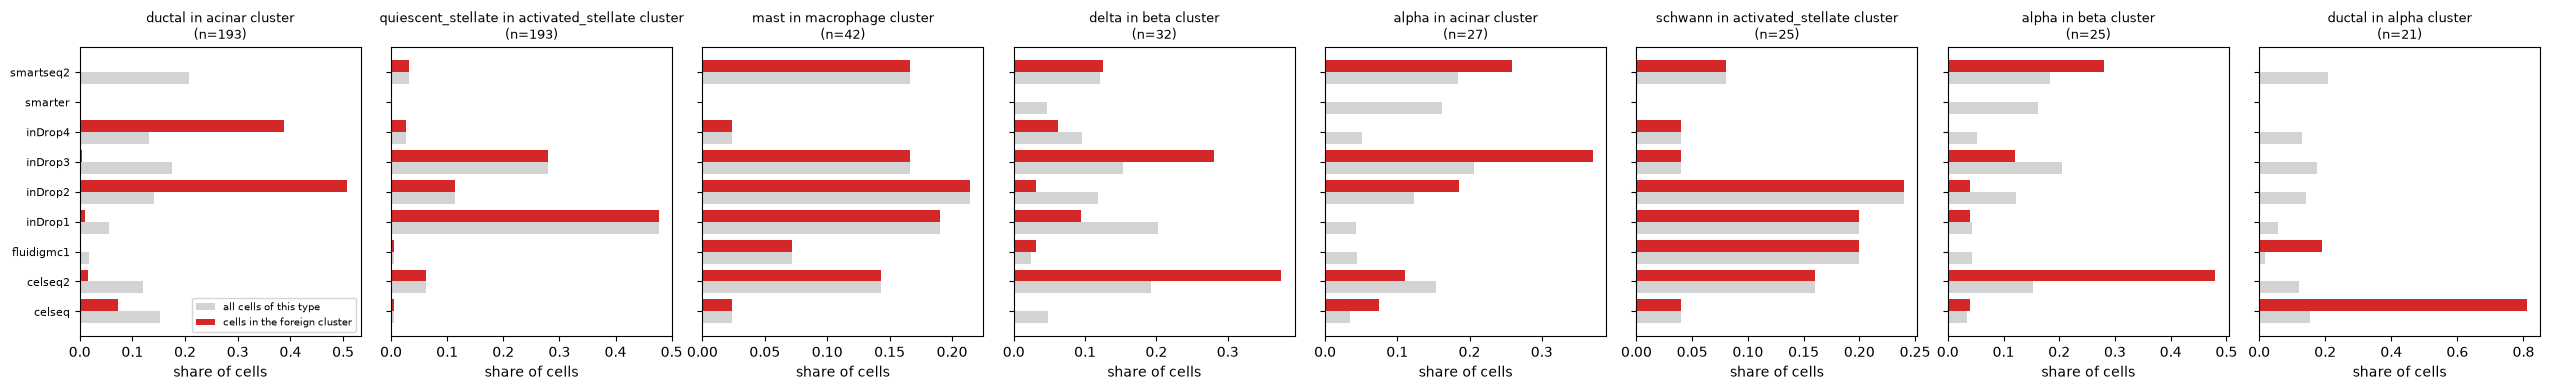

In [5]:
fig, axes = plt.subplots(1, len(groups_tech), figsize=(3.2 * len(groups_tech), 4), sharey=True)
techs = sorted(obs["tech"].unique())
for ax, (_, g) in zip(np.atleast_1d(axes), groups_tech.iterrows()):
    sel = minority[(minority["harmony_cluster"] == g["harmony_cluster"]) & (minority["celltype"] == g["celltype"])]
    observed = sel["tech"].value_counts(normalize=True).reindex(techs).fillna(0)
    expected = tech_share_all.loc[g["celltype"]].reindex(techs).fillna(0)
    y = np.arange(len(techs))
    ax.barh(y - 0.2, expected, 0.4, label="all cells of this type", color="lightgrey")
    ax.barh(y + 0.2, observed, 0.4, label="cells in the foreign cluster", color="#d62728")
    ax.set_yticks(y); ax.set_yticklabels(techs, fontsize=8)
    ax.set_title(f"{g['celltype']} in {g['cluster_dominant']} cluster\n(n={g['n']})", fontsize=9)
    ax.set_xlabel("share of cells")
np.atleast_1d(axes)[0].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig("../results/figures/08_A_merges_by_tech.png", dpi=150)
plt.show()

### A.2 — The `ductal` cells in the acinar cluster: what do they express?

`06` read this group as possible acinar-to-ductal metaplasia. Note the direction: these
are cells *annotated* ductal that cluster with acinar cells. Three profiles are compared,
all from the same two batches so that technology cannot explain the difference: the
ductal cells in the acinar cluster, ductal cells that cluster with ductal cells, and
acinar cells in the acinar cluster.

batches used for the comparison: ['inDrop2', 'inDrop4', 'celseq']
{'ductal, in ACINAR cluster': 187, 'ductal, in ductal cluster': 699, 'acinar, in acinar cluster': 233}


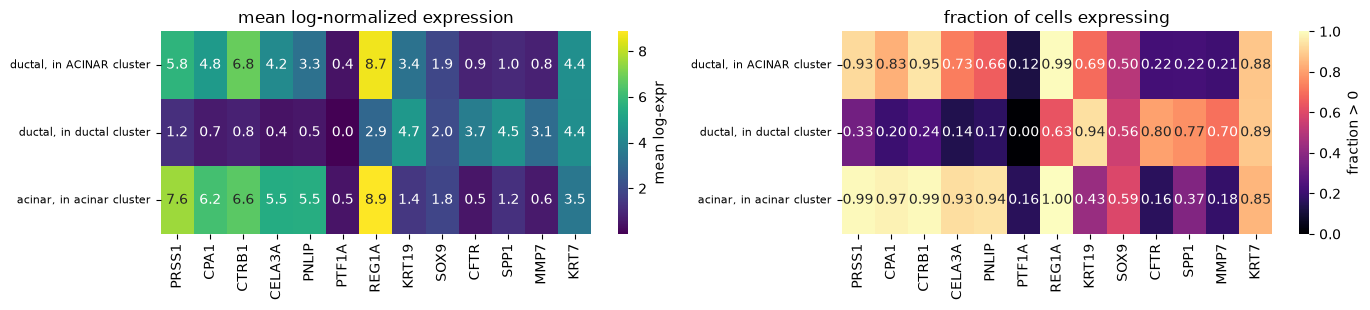

,total_counts,n_genes_by_counts
"ductal, in ACINAR cluster",8673.000000,2507.0
"ductal, in ductal cluster",6259.350586,2597.0
"acinar, in acinar cluster",11605.367188,3386.0


In [6]:
acinar_cl = dominant[dominant == "acinar"].index[0]
ductal_cl = dominant[dominant == "ductal"].index[0]
grpA = groups_tech[(groups_tech["celltype"] == "ductal") & (groups_tech["cluster_dominant"] == "acinar")].iloc[0]
techs_A = minority[(minority["harmony_cluster"] == str(acinar_cl)) & (minority["celltype"] == "ductal")]["tech"].value_counts()
techs_A = techs_A[techs_A >= 10].index.tolist()
print("batches used for the comparison:", techs_A)

in_batches = obs["tech"].isin(techs_A)
sets_A = {
    "ductal, in ACINAR cluster": obs.index[in_batches & (obs["harmony_cluster"] == str(acinar_cl)) & (obs["celltype"] == "ductal")],
    "ductal, in ductal cluster":  obs.index[in_batches & (obs["harmony_cluster"] == str(ductal_cl)) & (obs["celltype"] == "ductal")],
    "acinar, in acinar cluster":  obs.index[in_batches & (obs["harmony_cluster"] == str(acinar_cl)) & (obs["celltype"] == "acinar")],
}
genes_A = MARKERS["acinar"] + MARKERS["ductal"]
meanA = pd.DataFrame({k: expr.loc[v, genes_A].mean() for k, v in sets_A.items()}).T
fracA = pd.DataFrame({k: (expr.loc[v, genes_A] > 0).mean() for k, v in sets_A.items()}).T
print({k: len(v) for k, v in sets_A.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 3.2))
sns.heatmap(meanA, annot=True, fmt=".1f", cmap="viridis", ax=axes[0], cbar_kws={"label": "mean log-expr"})
axes[0].set_title("mean log-normalized expression")
sns.heatmap(fracA, annot=True, fmt=".2f", cmap="magma", vmin=0, vmax=1, ax=axes[1], cbar_kws={"label": "fraction > 0"})
axes[1].set_title("fraction of cells expressing")
for ax in axes: ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("../results/figures/08_A_ductal_in_acinar_markers.png", dpi=150)
plt.show()

libA = pd.DataFrame({k: obs.loc[v, ["total_counts", "n_genes_by_counts"]].median() for k, v in sets_A.items()}).T
libA

## Part B — Which hold-out errors survive five seeds?

A cell is a **stable error** if scANVI mislabels it in at least 4 of the 5 seeds, an
**unstable error** if in 1–3, and **correct** if in none. The reference run from notebook
04 is kept for comparison, but the stable/unstable split — not the single run — defines
what gets examined below.

In [7]:
sp = seed_preds.copy()
wrong = sp[PRED_COLS].ne(sp["celltype"], axis=0)
sp["n_wrong"] = wrong.sum(axis=1)
sp["mean_conf"] = sp[CONF_COLS].mean(axis=1)
sp["ref_pred"] = obs.loc[sp.index, "scanvi_pred_ref"].values
sp["ref_wrong"] = sp["ref_pred"] != sp["celltype"]

def majority_wrong_label(row):
    labs = [row[c] for c in PRED_COLS if row[c] != row["celltype"]]
    return pd.Series(labs).mode().iloc[0] if labs else "—"

sp["pred_when_wrong"] = sp.apply(majority_wrong_label, axis=1)
sp["status"] = np.select([sp["n_wrong"] == 0, sp["n_wrong"] >= 4],
                         ["correct (5/5)", "stable error (≥4/5)"], default="unstable error (1–3/5)")
sp["status"] = pd.Categorical(sp["status"], ["correct (5/5)", "unstable error (1–3/5)", "stable error (≥4/5)"])

status_by_type = pd.crosstab(sp["celltype"], sp["status"])
print(status_by_type.to_string())
print(f"\nreference-run errors: {sp['ref_wrong'].sum()} | of which stable across seeds: "
      f"{(sp['ref_wrong'] & (sp['n_wrong'] >= 4)).sum()} | unstable: {(sp['ref_wrong'] & (sp['n_wrong'].between(1, 3))).sum()} | "
      f"correct in all 5 seeds despite being wrong in the reference run: {(sp['ref_wrong'] & (sp['n_wrong'] == 0)).sum()}")
print(f"cells wrong in ≥4/5 seeds but correct in the reference run: {((~sp['ref_wrong']) & (sp['n_wrong'] >= 4)).sum()}")

status              correct (5/5)  unstable error (1–3/5)  stable error (≥4/5)
celltype                                                                      
acinar                        168                      19                    1
activated_stellate             53                       2                    0
alpha                         955                      31                   22
beta                          283                      15                   10
delta                         124                       3                    0
ductal                        438                       4                    2
endothelial                    21                       0                    0
epsilon                         7                       1                    0
gamma                         211                       2                    0
macrophage                      7                       0                    0
mast                            6                   

In [8]:
stable = sp[sp["n_wrong"] >= 4]
pairs = (stable.groupby(["celltype", "pred_when_wrong"], observed=True).size().rename("n_stable")
         .reset_index().sort_values("n_stable", ascending=False).reset_index(drop=True))
unstable_pairs = (sp[sp["n_wrong"].between(1, 3)].groupby(["celltype", "pred_when_wrong"], observed=True).size()
                  .rename("n_unstable").reset_index())
pairs = pairs.merge(unstable_pairs, how="outer").fillna(0).astype({"n_stable": int, "n_unstable": int})
pairs = pairs.sort_values(["n_stable", "n_unstable"], ascending=False).reset_index(drop=True)
pairs["true_marker"] = pairs["celltype"].map(TYPE_MARKER)
pairs["pred_marker"] = pairs["pred_when_wrong"].map(TYPE_MARKER)
pairs

,celltype,pred_when_wrong,n_stable,n_unstable,true_marker,pred_marker
0,alpha,gamma,8,13,GCG,PPY
1,beta,delta,7,5,INS,SST
2,alpha,acinar,7,0,GCG,PRSS1
3,alpha,beta,3,4,GCG,INS
4,beta,gamma,2,1,INS,PPY
5,alpha,delta,2,0,GCG,SST
6,acinar,ductal,1,19,PRSS1,KRT19
7,alpha,quiescent_stellate,1,1,GCG,RGS5
8,beta,ductal,1,1,INS,KRT19
9,alpha,activated_stellate,1,0,GCG,COL1A1


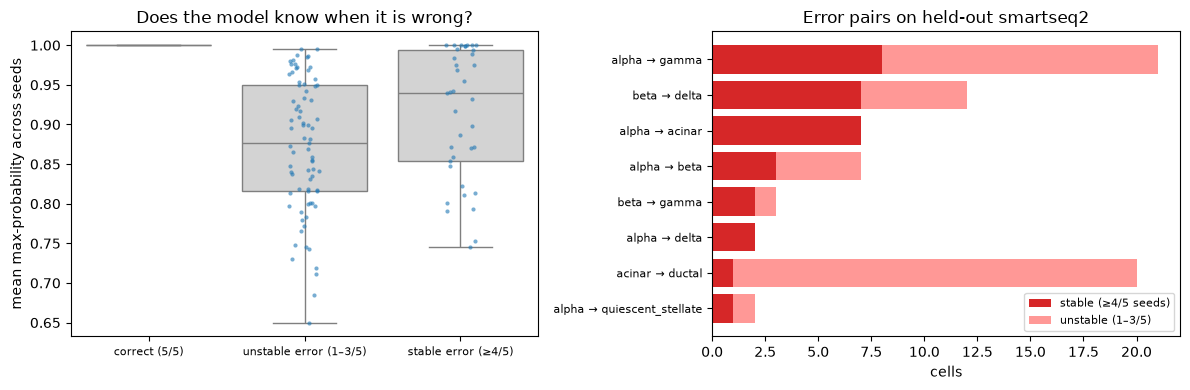

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=sp, x="status", y="mean_conf", ax=axes[0], showfliers=False, color="lightgrey")
sns.stripplot(data=sp[sp["status"] != "correct (5/5)"], x="status", y="mean_conf", ax=axes[0], size=3, alpha=0.6)
axes[0].set_ylabel("mean max-probability across seeds"); axes[0].set_xlabel("")
axes[0].set_title("Does the model know when it is wrong?")
axes[0].tick_params(axis="x", labelsize=8)
top = pairs.head(8)
axes[1].barh(range(len(top)), top["n_stable"], color="#d62728", label="stable (≥4/5 seeds)")
axes[1].barh(range(len(top)), top["n_unstable"], left=top["n_stable"], color="#ff9896", label="unstable (1–3/5)")
axes[1].set_yticks(range(len(top))); axes[1].set_yticklabels([f"{a} → {b}" for a, b in zip(top["celltype"], top["pred_when_wrong"])], fontsize=8)
axes[1].invert_yaxis(); axes[1].set_xlabel("cells"); axes[1].legend(fontsize=8); axes[1].set_title("Error pairs on held-out smartseq2")
plt.tight_layout()
plt.savefig("../results/figures/08_B_error_stability.png", dpi=150)
plt.show()

## Part C — Marker profiles of the stable errors

For each error pair *true → predicted* with at least 3 stable cells, three groups from the
same technology are compared: correctly labelled cells of the true type, the stable
errors, and correctly labelled cells of the predicted type. If the errors look like the
predicted type, the annotation is the likelier problem (H1). If they express the defining
markers of *both* types, it is a doublet (H2) or a genuine co-expressing cell (H4) — and
Parts D and E separate those two.

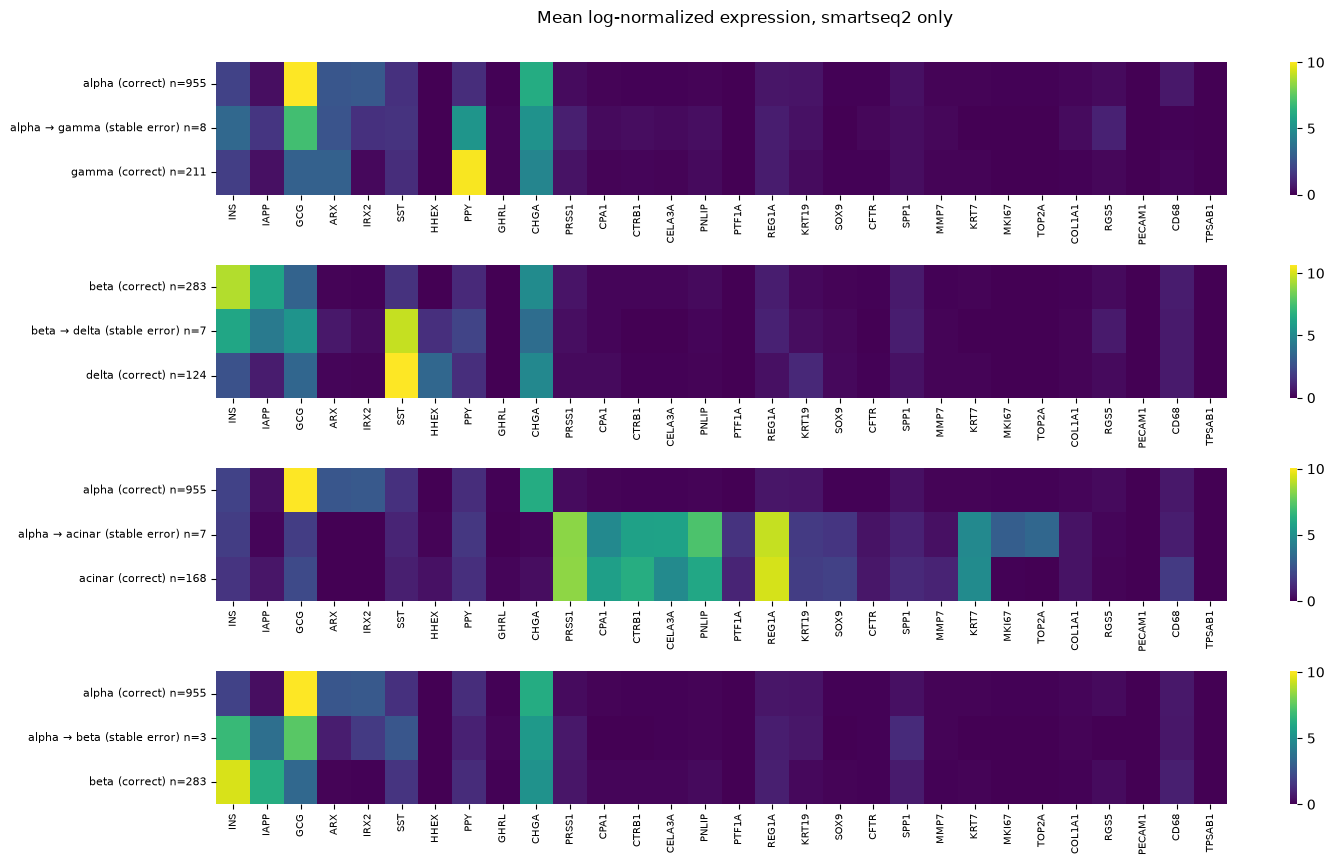

In [10]:
MIN_STABLE = 3
focus = pairs[pairs["n_stable"] >= MIN_STABLE].copy()
ho_obs = obs[obs["tech"] == HOLDOUT_TECH]
correct_cells = sp.index[sp["n_wrong"] == 0]

def group_sets(t, p):
    return {
        f"{t} (correct)": [c for c in correct_cells if obs.at[c, "celltype"] == t],
        f"{t} → {p} (stable error)": stable.index[(stable["celltype"] == t) & (stable["pred_when_wrong"] == p)].tolist(),
        f"{p} (correct)": [c for c in correct_cells if obs.at[c, "celltype"] == p],
    }

fig, axes = plt.subplots(len(focus), 1, figsize=(15, 1.9 * len(focus) + 1))
for ax, (_, pr) in zip(np.atleast_1d(axes), focus.iterrows()):
    sets = group_sets(pr["celltype"], pr["pred_when_wrong"])
    m = pd.DataFrame({f"{k} n={len(v)}": expr.loc[v, MARKER_LIST].mean() for k, v in sets.items()}).T
    sns.heatmap(m, cmap="viridis", ax=ax, cbar=True, annot=False)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.suptitle("Mean log-normalized expression, smartseq2 only", y=1.0)
plt.tight_layout()
plt.savefig("../results/figures/08_C_pair_markers.png", dpi=150)
plt.show()

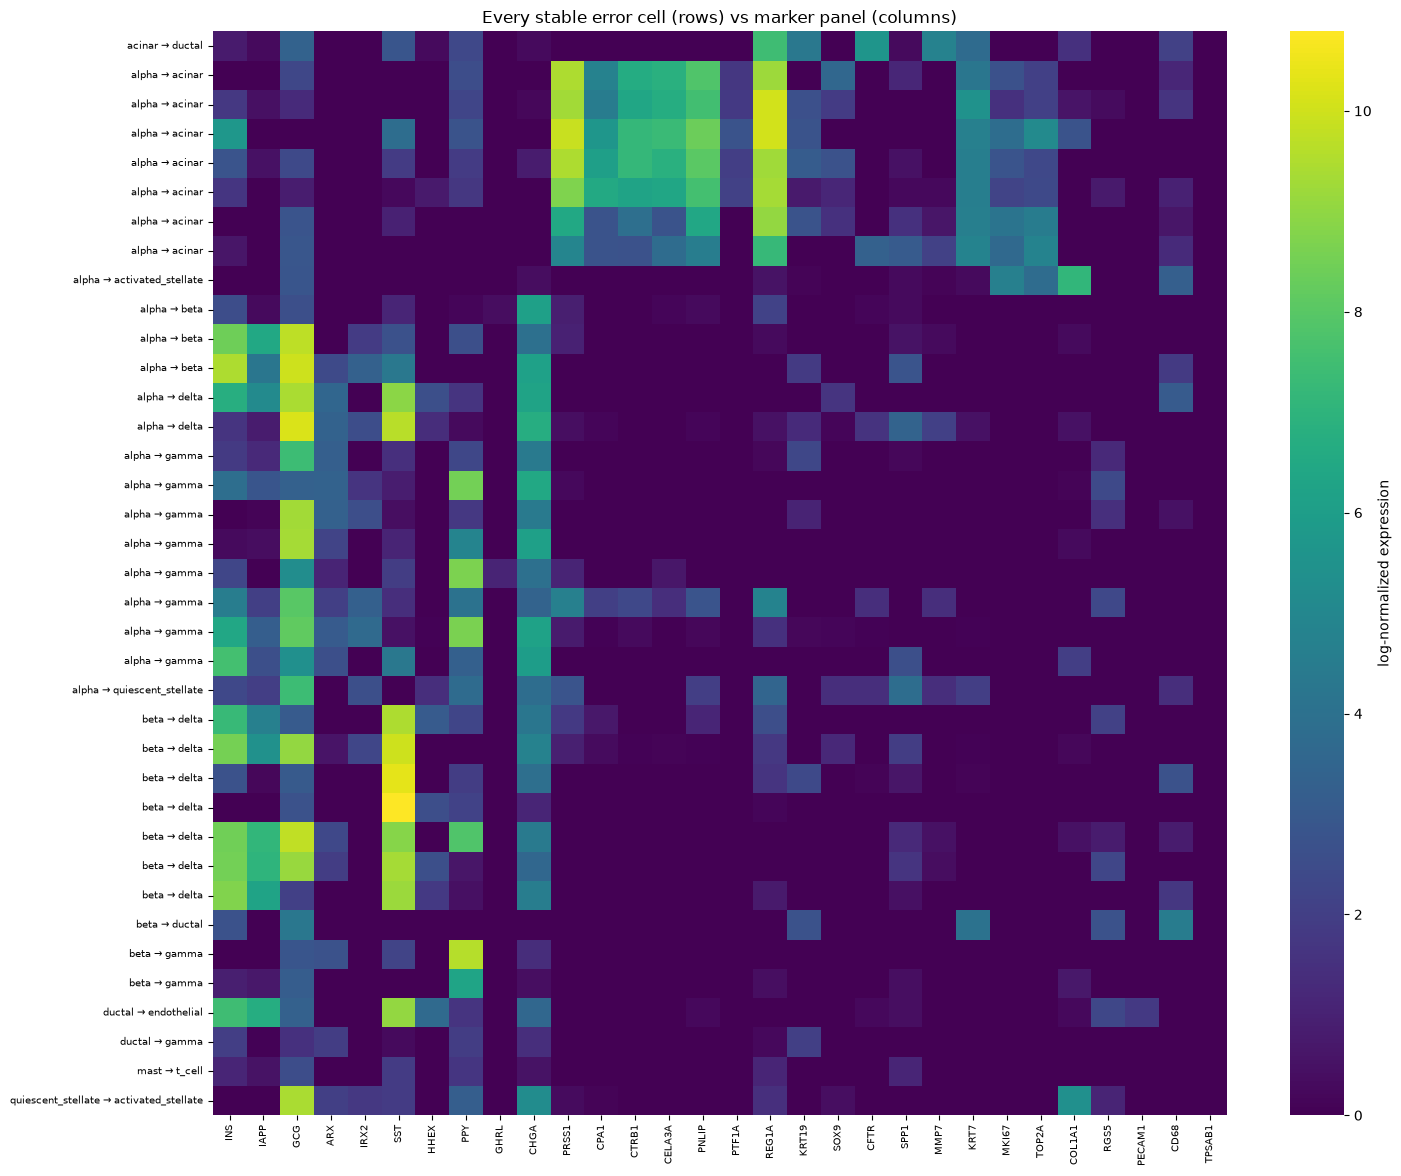

In [11]:
# per-cell view of every stable error: which markers does each cell actually carry?
cells_stable = stable.sort_values(["celltype", "pred_when_wrong"])
labels = [f"{t} → {p}" for t, p in zip(cells_stable["celltype"], cells_stable["pred_when_wrong"])]
M = expr.loc[cells_stable.index, MARKER_LIST].copy()
M.index = labels
fig, ax = plt.subplots(figsize=(15, 0.28 * len(M) + 1.5))
sns.heatmap(M, cmap="viridis", ax=ax, cbar_kws={"label": "log-normalized expression"})
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_title("Every stable error cell (rows) vs marker panel (columns)")
plt.tight_layout()
plt.savefig("../results/figures/08_C_stable_cells.png", dpi=150)
plt.show()

In [12]:
# Co-expression test per pair.  "Above the 95th percentile of correct true-type cells" means the
# predicted-type marker is at a level a normal cell of the true type essentially never shows.
rows = []
for _, pr in focus.iterrows():
    t, p = pr["celltype"], pr["pred_when_wrong"]
    tm, pm = TYPE_MARKER.get(t), TYPE_MARKER.get(p)
    sets = group_sets(t, p)
    corr_t, err, corr_p = list(sets.values())
    row = {"pair": f"{t} → {p}", "n_stable": len(err), "true_marker": tm, "pred_marker": pm}
    if pm is not None:
        q95 = expr.loc[corr_t, pm].quantile(0.95)
        row[f"pred_marker: median in errors"] = round(expr.loc[err, pm].median(), 2)
        row[f"pred_marker: median in correct {t}"] = round(expr.loc[corr_t, pm].median(), 2)
        row[f"pred_marker: median in correct {p}"] = round(expr.loc[corr_p, pm].median(), 2)
        row["errors with pred_marker > p95 of true type"] = f"{(expr.loc[err, pm] > q95).mean():.0%}"
    if tm is not None:
        q05 = expr.loc[corr_t, tm].quantile(0.05)
        row["true_marker: median in errors"] = round(expr.loc[err, tm].median(), 2)
        row["true_marker: median in correct true type"] = round(expr.loc[corr_t, tm].median(), 2)
        row["errors with true_marker < p05 of true type"] = f"{(expr.loc[err, tm] < q05).mean():.0%}"
    rows.append(row)
coexp = pd.DataFrame(rows)
coexp.T

,0,1,2,3
pair,alpha → gamma,beta → delta,alpha → acinar,alpha → beta
n_stable,8,7,7,3
true_marker,GCG,INS,GCG,GCG
pred_marker,PPY,SST,PRSS1,INS
pred_marker: median in errors,4.47,9.48,9.3,8.39
pred_marker: median in correct alpha,0.92,NaN,0.0,1.86
pred_marker: median in correct gamma,10.01,NaN,NaN,NaN
errors with pred_marker > p95 of true type,62%,100%,100%,67%
true_marker: median in errors,7.7,8.46,2.3,9.71
true_marker: median in correct true type,10.19,9.45,10.19,10.19


## Part D — Doublets

Scrublet, run separately per technology (`batch_key="tech"`), on the reconstructed counts.
Two caveats stated up front: `smartseq2` is plate-based, so true doublets should be rare
and the simulated-doublet model was designed for droplet data; and the counts layer is a
reconstruction, not raw UMIs. The comparison that matters is *relative* — do the stable
errors score higher than correctly labelled cells of the same type from the same plates?

In [13]:
sub.X = sub.layers["counts"].copy()
sc.pp.scrublet(sub, batch_key="tech", random_state=0, verbose=False)
obs.loc[sub.obs_names, "doublet_score"] = sub.obs["doublet_score"].values
obs.loc[sub.obs_names, "predicted_doublet"] = sub.obs["predicted_doublet"].values
print(sub.obs.groupby("tech", observed=True)["doublet_score"].describe()[["count", "50%", "75%", "max"]])
print("\npredicted doublets per tech:", sub.obs.groupby("tech", observed=True)["predicted_doublet"].mean().round(3).to_dict())

            count       50%       75%       max
tech                                           
inDrop2    1724.0  0.043022  0.064295  0.453237
inDrop4    1303.0  0.039080  0.056934  0.415385
smartseq2  2394.0  0.033386  0.049049  0.486486

predicted doublets per tech: {'inDrop2': 0.003, 'inDrop4': 0.003, 'smartseq2': 0.001}


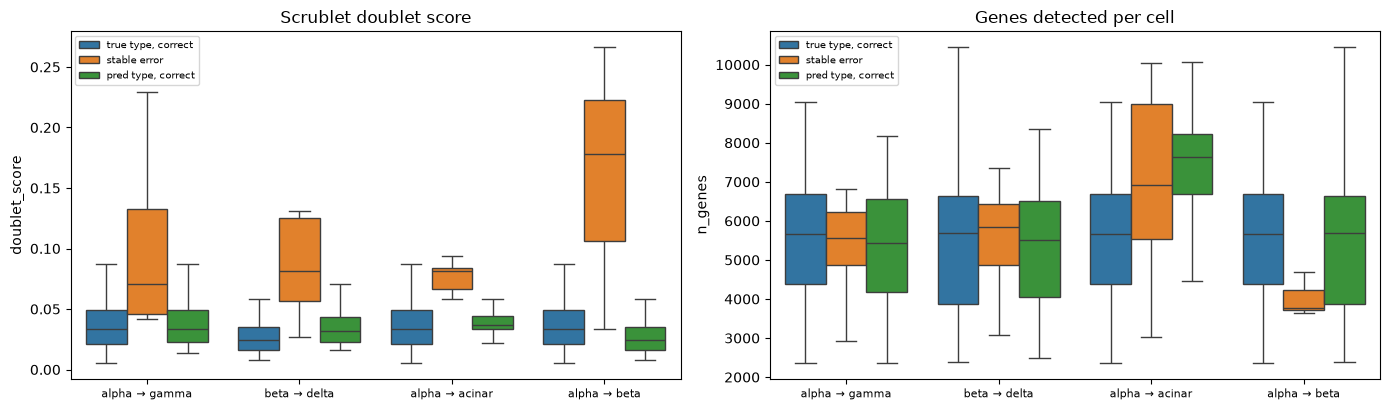

,0,1,2,3
pair,alpha → gamma,beta → delta,alpha → acinar,alpha → beta
n_stable,8,7,7,3
"doublet score, median errors",0.071,0.081,0.081,0.178
"doublet score, median correct true type",0.033,0.024,0.033,0.033
p (errors > correct),0.000287,0.000131,4.69e-05,0.0228
predicted doublets among errors,0%,0%,0%,0%
"n_genes, median errors",5572,5841,6931,3779
"n_genes, median correct true type",5671,5695,5671,5671
p n_genes (errors > correct),0.622,0.401,0.039,0.964


In [14]:
rows, plot_frames = [], []
for _, pr in focus.iterrows():
    t, p = pr["celltype"], pr["pred_when_wrong"]
    sets = group_sets(t, p)
    corr_t, err, corr_p = list(sets.values())
    for name, cells in zip(["true type, correct", "stable error", "pred type, correct"], [corr_t, err, corr_p]):
        plot_frames.append(pd.DataFrame({"pair": f"{t} → {p}", "group": name,
                                         "doublet_score": obs.loc[cells, "doublet_score"].values,
                                         "n_genes": obs.loc[cells, "n_genes_by_counts"].values,
                                         "total_counts": obs.loc[cells, "total_counts"].values}))
    u = mannwhitneyu(obs.loc[err, "doublet_score"], obs.loc[corr_t, "doublet_score"], alternative="greater")
    ug = mannwhitneyu(obs.loc[err, "n_genes_by_counts"], obs.loc[corr_t, "n_genes_by_counts"], alternative="greater")
    rows.append({"pair": f"{t} → {p}", "n_stable": len(err),
                 "doublet score, median errors": round(obs.loc[err, "doublet_score"].median(), 3),
                 "doublet score, median correct true type": round(obs.loc[corr_t, "doublet_score"].median(), 3),
                 "p (errors > correct)": f"{u.pvalue:.3g}",
                 "predicted doublets among errors": f"{obs.loc[err, 'predicted_doublet'].astype(float).mean():.0%}",
                 "n_genes, median errors": int(obs.loc[err, "n_genes_by_counts"].median()),
                 "n_genes, median correct true type": int(obs.loc[corr_t, "n_genes_by_counts"].median()),
                 "p n_genes (errors > correct)": f"{ug.pvalue:.3g}"})
doublet_table = pd.DataFrame(rows)
plot_df = pd.concat(plot_frames)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(data=plot_df, x="pair", y="doublet_score", hue="group", ax=axes[0], showfliers=False)
sns.boxplot(data=plot_df, x="pair", y="n_genes", hue="group", ax=axes[1], showfliers=False)
axes[0].set_title("Scrublet doublet score"); axes[1].set_title("Genes detected per cell")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8); ax.set_xlabel(""); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("../results/figures/08_D_doublets.png", dpi=150)
plt.show()
doublet_table.T

## Part E — Ambient background per technology

How much hormone signal does a cell that should have none (acinar, ductal, stellate,
endothelial, immune) carry, and how much acinar-enzyme signal does an endocrine cell
carry? This is the per-technology floor of contamination against which any
"co-expression" has to be judged. If the foreign marker in an error cell sits at the
floor, H3 (ambient) is the explanation; if it sits far above it, it isn't.

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


            hormone counts in non-endocrine cells (median %)  acinar-enzyme counts in endocrine cells (median %)
tech                                                                                                            
celseq                                                  0.12                                                0.02
celseq2                                                 0.54                                                0.01
fluidigmc1                                              0.01                                                0.00
inDrop1                                                 0.66                                                0.02
inDrop2                                                 0.18                                                0.00
inDrop3                                                 0.05                                                0.04
inDrop4                                                 0.11                                    

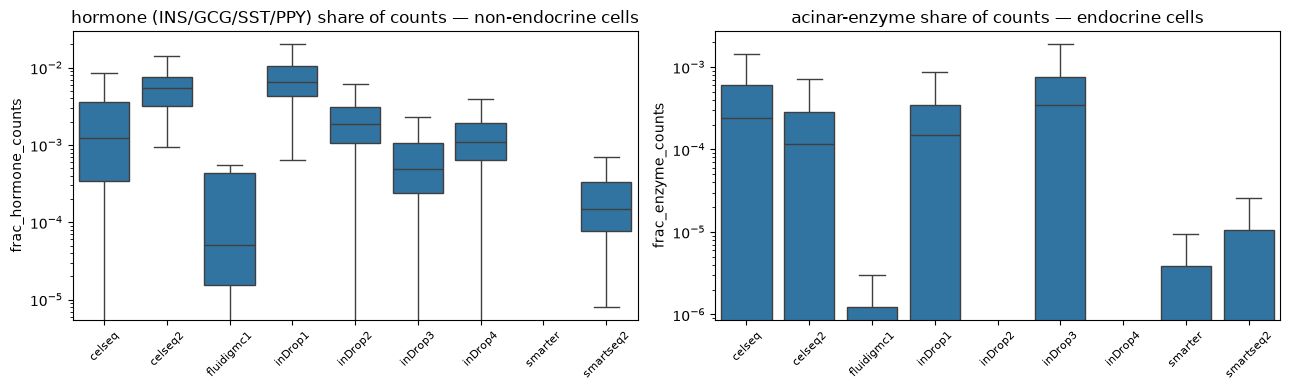

In [15]:
non_endocrine = ["acinar", "ductal", "activated_stellate", "quiescent_stellate", "endothelial", "macrophage", "mast", "schwann"]
endocrine = ["alpha", "beta", "delta", "gamma", "epsilon"]
amb = pd.DataFrame({
    "hormone counts in non-endocrine cells (median %)": obs[obs["celltype"].isin(non_endocrine)].groupby("tech", observed=True)["frac_hormone_counts"].median() * 100,
    "acinar-enzyme counts in endocrine cells (median %)": obs[obs["celltype"].isin(endocrine)].groupby("tech", observed=True)["frac_enzyme_counts"].median() * 100,
}).round(2)
print(amb.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=obs[obs["celltype"].isin(non_endocrine)], x="tech", y="frac_hormone_counts", ax=axes[0], showfliers=False)
axes[0].set_yscale("log"); axes[0].set_title("hormone (INS/GCG/SST/PPY) share of counts — non-endocrine cells")
sns.boxplot(data=obs[obs["celltype"].isin(endocrine)], x="tech", y="frac_enzyme_counts", ax=axes[1], showfliers=False)
axes[1].set_yscale("log"); axes[1].set_title("acinar-enzyme share of counts — endocrine cells")
for ax in axes: ax.tick_params(axis="x", rotation=45, labelsize=8); ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../results/figures/08_E_ambient_by_tech.png", dpi=150)
plt.show()

In [16]:
# For each pair: the predicted-type marker in the errors vs the ambient floor of the same
# technology (= its level in correct cells of the true type, which should not express it at all).
rows = []
for _, pr in focus.iterrows():
    t, p = pr["celltype"], pr["pred_when_wrong"]
    pm = TYPE_MARKER.get(p)
    if pm is None: continue
    sets = group_sets(t, p)
    corr_t, err, corr_p = list(sets.values())
    floor = expr.loc[corr_t, pm]
    rows.append({"pair": f"{t} → {p}", "pred_marker": pm,
                 "floor (median in correct true type)": round(floor.median(), 2),
                 "floor p95": round(floor.quantile(0.95), 2),
                 "errors: median": round(expr.loc[err, pm].median(), 2),
                 "errors: fraction above floor p95": f"{(expr.loc[err, pm] > floor.quantile(0.95)).mean():.0%}",
                 "correct pred type: median": round(expr.loc[corr_p, pm].median(), 2)})
pd.DataFrame(rows).T

,0,1,2,3
pair,alpha → gamma,beta → delta,alpha → acinar,alpha → beta
pred_marker,PPY,SST,PRSS1,INS
floor (median in correct true type),0.92,1.48,0.0,1.86
floor p95,3.49,3.53,1.66,4.7
errors: median,4.47,9.48,9.3,8.39
errors: fraction above floor p95,62%,100%,100%,67%
correct pred type: median,10.01,10.72,8.57,9.45


## Part F — Verdicts

One row per error pair, assembled from Parts B–E. The verdict column is filled in by
hand after reading the numbers — it is a judgement, not a threshold.

In [17]:
verdict = (focus[["celltype", "pred_when_wrong", "n_stable", "n_unstable"]]
           .assign(pair=lambda d: d["celltype"] + " → " + d["pred_when_wrong"])
           .merge(coexp[["pair", "errors with pred_marker > p95 of true type", "errors with true_marker < p05 of true type"]], on="pair", how="left")
           .merge(doublet_table[["pair", "doublet score, median errors", "doublet score, median correct true type",
                                 "p (errors > correct)", "predicted doublets among errors",
                                 "n_genes, median errors", "n_genes, median correct true type"]], on="pair", how="left")
           .drop(columns=["celltype", "pred_when_wrong"]))
verdict["mean confidence (stable errors)"] = [round(stable.loc[(stable["celltype"] == t) & (stable["pred_when_wrong"] == p), "mean_conf"].mean(), 2)
                                              for t, p in zip(focus["celltype"], focus["pred_when_wrong"])]
verdict.to_csv("../results/error_anatomy_pairs.csv", index=False)
sp.join(obs[["doublet_score", "predicted_doublet", "n_genes_by_counts", "total_counts"]]).to_csv("../results/error_anatomy_cells_smartseq2.csv")
groups_tech.to_csv("../results/error_anatomy_harmony_merges.csv", index=False)
print("Saved: results/error_anatomy_pairs.csv, error_anatomy_cells_smartseq2.csv, error_anatomy_harmony_merges.csv")
verdict.T

Saved: results/error_anatomy_pairs.csv, error_anatomy_cells_smartseq2.csv, error_anatomy_harmony_merges.csv


,0,1,2,3
n_stable,8,7,7,3
n_unstable,13,5,0,4
pair,alpha → gamma,beta → delta,alpha → acinar,alpha → beta
errors with pred_marker > p95 of true type,62%,100%,100%,67%
errors with true_marker < p05 of true type,75%,43%,100%,33%
"doublet score, median errors",0.071,0.081,0.081,0.178
"doublet score, median correct true type",0.033,0.024,0.033,0.033
p (errors > correct),0.000287,0.000131,4.69e-05,0.0228
predicted doublets among errors,0%,0%,0%,0%
"n_genes, median errors",5572,5841,6931,3779


## Conclusions

**A third of what a single run calls an error is initialization noise.** Of the 64
held-out cells the reference run (notebook 04) mislabelled, 34 are wrong in ≥ 4 of 5
seeds, 19 are wrong in only 1–3 seeds, and 11 are never wrong again; 3 cells the
reference run got right are stable errors in the seed sweep. The first pass's two
"recurring" errors behave differently once this is known. **acinar → ductal** is 1 stable
cell and 19 unstable ones — a boundary the model wobbles across, not a reproducible
confusion. **alpha → gamma** is 8 stable and 13 unstable: a real group of GCG/PPY
intermediate cells plus a wide soft margin around it. The claim in `06` that these
"survived four independent training runs" was based on counting cells per run, not on
tracking which cells; the same count can hide almost complete turnover.

**The stable/unstable split is itself only as good as five seeds.** The previous version
of this sweep (Linux, scvi-tools 1.4) found 30 stable / 24 unstable among 59 reference
errors, with alpha → gamma at 3 / 20 and acinar → ductal at 3 / 13. The two pairs with
a clear marker signature — alpha → acinar (7 / 0) and beta → delta (7 / 5) — came out
identical in both sweeps; the borderline pairs moved. Cells that are wrong in 3 of 5 seeds
in one sweep and 4 of 5 in another are exactly what a threshold on five draws produces.

**Verdicts per stable error pair** (smartseq2 hold-out, pairs with ≥ 3 stable cells;
markers, doublet score, library size, ambient floor from Parts C–E):

| Error (true → predicted) | stable / unstable | Evidence | Verdict |
|---|---|---|---|
| alpha → acinar | 7 / 0 | acinar enzyme program in all 7 (PRSS1 median 9.3 vs 8.6 in acinar cells; CPA1, CTRB1, CELA3A, PNLIP, REG1A expressed), GCG at 2.3 vs 10.2 in alpha cells, gene count acinar-like (6931 vs 5671, p = 0.04), confidence 0.98; 5 of 7 share one barcode prefix | **H1 — annotation.** These are acinar cells labelled alpha in the source annotation. The model is right and the label is wrong, which also means the reported accuracy is a lower bound. The shared barcode prefix suggests one donor or plate (inferred from cell names; donor identity is not in the object). |
| alpha → gamma | 8 / 13 | PPY median 4.5 (alpha 0.9, gamma 10.0), above the alpha p95 in 62 %; GCG median 7.7 vs 10.2, below the alpha p05 in 75 %; three cells carry PPY ≥ 8.5, at gamma level; gene count normal (5572 vs 5671); doublet score 0.071 vs 0.033, no scrublet calls | **A GCG/PPY continuum.** Two cells (PPY ≥ 8.5, GCG ≤ 5.2) look like gamma cells labelled alpha (H1); the other six carry both hormones at intermediate levels, some with INS as well — the PP/alpha boundary is graded in this data, and the model's 13 unstable flips are on the same margin. Not a doublet signature (normal library size). |
| beta → delta | 7 / 5 | SST 8.8–10.8 in every cell (delta median 10.7; beta floor 1.5, p95 3.5); INS below the beta p05 in 3/7 (two near zero); five keep INS at 7.3–8.8, three of them also carry GCG ≥ 9; doublet score 0.081 vs 0.024 (p = 1e-4) but gene count normal (5841 vs 5695, p = 0.40); no scrublet calls; smartseq2 ambient hormone floor 0.01 % | **Mixed.** The two INS-negative cells are delta cells labelled beta (H1). The rest are *polyhormonal* profiles (INS + SST ± GCG) with a normal library size — H4 (genuine co-expressing cell) is the best-supported reading, but a sorted multiplet (H2) cannot be excluded from expression alone; the elevated Scrublet score is what any mixture looks like, doublet or not. Ambient (H3) is excluded: the smartseq2 floor is three orders of magnitude lower. |
| alpha → beta | 3 / 4 | two cells INS 8.4–9.5 with GCG 9.7–10.0; one low-content cell with every marker low; doublet score 0.178 vs 0.033 but the *lowest* gene count of any group (3779 vs 5671) | **H4 candidate, H2 not excluded.** Bihormonal INS⁺GCG⁺ profile without the library-size signature of a doublet; the third cell is simply too sparse to call. |

acinar → ductal no longer has enough stable cells for this table. Its one stable cell has
no acinar enzymes except REG1A, moderate KRT19 and a low gene count (3888) — a low-quality
cell — and its 19 unstable ones have a normal gene count (7423 vs 7629). Nothing here
supports acinar-to-ductal metaplasia, which the first pass had floated.

**The Harmony merges (Part A) are batch-specific, not tissue-wide.** The 193 `ductal`
cells in the acinar cluster come almost entirely from two of the four Baron `inDrop`
batches (51 % inDrop2, 39 % inDrop4; expected 14 % / 13 %) and express the acinar enzyme
program at near-acinar levels with only weak ductal markers (heatmap above). Whether that
is a labelling convention in the Baron annotation or a real acinar-like ductal population
in two donors cannot be settled without donor metadata — but it does not appear in the
other seven batches, so it is not evidence for acinar-to-ductal metaplasia across the
atlas. Two more merges are batch-driven (ductal in the alpha cluster: 81 % celseq; alpha
in the beta cluster: 48 % celseq2); the stellate and immune merges are proportional across
technologies and are what `06` said they were — rare types and cell states collapsing at
coarse resolution. Harmony is deterministic, so Part A is identical to the previous version.

**Confidence is not a reliable error flag.** Stable errors have a mean max-probability of
0.81–0.98 per pair against 0.998 for correct cells. The most confident errors (alpha →
acinar, 0.98) are the ones where the model is right and the annotation is wrong —
confidence tracks how clean the expression profile is, not whether the label agrees.

**Limitations.** Numbers of stable cells are small (3–8 per pair), so everything above is
per-cell reading of expression, not statistics on a population, and the stable/unstable
boundary moves between five-seed sweeps for borderline pairs. The original per-study
annotations and donor identities are not in the benchmark object; with them, H1 could be
tested directly and the Baron finding could be tied to donors. Scrublet was designed for
droplet data and run here on reconstructed counts; its scores are used only relatively,
and it called no doublets among the error cells. Distinguishing a genuine polyhormonal cell
from a sorted multiplet needs an orthogonal signal — imaging, protein, or a doublet
detector that uses genotype — and is the natural next step.